In [1]:
import scanpy as sc
#import session_info
import os
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import math
#from plotnine import *
#import scvi
import os


#import celltypist
#import scanpy
# verbosity: errors (0), warnings (1), info (2), hints (3)
%matplotlib inline
sc.settings.verbosity = 0




/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: 

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
#%matplotlib inline
sc.settings.figdir = "supp"
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(18,18),
                              vector_friendly=True
                             )

# scRNA

In [3]:
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered'
adata=sc.read_h5ad(PATH)
adata_5k=adata[adata.obs["tech"]=="xenium"].copy()
del(adata)
import gc
gc.collect()


def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata_5k.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata_5k.var_names]
    return LIST





In [4]:
sc.pp.normalize_total(adata_5k, target_sum=1e4)
sc.pp.log1p(adata_5k)

# AD

In [5]:
VMAX_PLOTS = 0.8
SPOT_SIZE=40


In [6]:
adata_5k_i=adata_5k[adata_5k.obs["disease_overall"]=="AD"]

In [7]:
AD_GENES_OT=  [
    "RUNX3",
    "FLG",
    "S100A9",
    "IL6R",
    "TNFSF4",
    "ID2",
    "CD207",
    "IL18RAP",
    "SATB1",
    "GLB1",
    "CD200R1",
    "KIAA1109",
    "IL7R",
    "CAMK4",
    "CDC42SE2",
    "SLC22A5",
    "ERGIC1",
    "TNF",
    "ATF6B",
    "AGER",
    "HLA-DRA",
    "TAGAP",
    "ZBTB10",
    "TRIB1",
    "IL2RA",
    "PRKCQ",
    "ADO",
    "PRR5L",
    "MAP3K11",
    "LRRC32",
    "DDX6",
    "FLI1",
    "RPS26",
    "IL22",
    "SRP54",
    "TRAF3",
    "RMI2",
    "CCR7",
    "STAT3",
    "DCAKD",
    "TBX21",
    "GNGT2",
    "CERS4",
    "RTEL1",
    "CSF2RB",
    "RERE",
    "TNFRSF1B",
    "CSF1",
    "CTSS",
    "RORC",
    "S100A7",
    "S100A12",
   # "AHSA2P",
    "MERTK",
    "NEU4",
    "IL15",
    "OTULINL",
    "LYRM7",
    "RGS14",
    "BACH2",
    "CREB5",
    "DOK2",
    "AGO2",
    "AQP3",
    "NR4A3",
    "MMP12",
    "SIK3",
    "PLXNC1",
    "GPR132",
    "PTPN2"
]
print(len(remove_markers(AD_GENES_OT)))
remove_markers(AD_GENES_OT)

35


['RUNX3',
 'IL6R',
 'TNFSF4',
 'CD207',
 'IL18RAP',
 'SATB1',
 'GLB1',
 'SLC22A5',
 'TNF',
 'AGER',
 'ZBTB10',
 'TRIB1',
 'IL2RA',
 'PRKCQ',
 'LRRC32',
 'DDX6',
 'FLI1',
 'IL22',
 'TRAF3',
 'CCR7',
 'STAT3',
 'TBX21',
 'CSF2RB',
 'TNFRSF1B',
 'CSF1',
 'RORC',
 'MERTK',
 'IL15',
 'BACH2',
 'CREB5',
 'NR4A3',
 'MMP12',
 'SIK3',
 'PLXNC1',
 'PTPN2']

In [8]:
adata_5k_i=adata_5k_i[adata_5k_i.obs["niche19"]!="Nonspecific/folded"]
adata_5k_i=adata_5k_i[~adata_5k_i.obs["niche19"].isna()]
adata_5k_ii=adata_5k_i[adata_5k_i.obs["Site_status"]=="Lesional"]



# Get counts per niche
counts = adata_5k_ii.obs["niche19"].value_counts()

# Identify categories with at least 10 cells
valid_niches = counts[counts > 10].index

# Subset AnnData to only those categories
adata_5k_ii = adata_5k_ii[adata_5k_ii.obs["niche19"].isin(valid_niches)].copy()


In [9]:
desired_order = [
    'Sebaceous_immune', 
    'Plasma_cell_niche','Plasma_cell_rich',
    'Tzone-like',
    'Epidermis_APChi',
    'EpidermisInflamm_late',
'EpidermisInflamm_mid',
    'Epidermis_basal_cycling',





     'Epidermis_late',
    'Epidermis_mid',
    'Epidermis_basal', #'Epidermis_mid1',
    'Papillary_dermis',
    'Small_BV', 'Large_BV','VenuleMuscle',
    'Reticular_dermis', 'Reticular_dermis_LErich','Reticular_dermis_LE_rich',
    'Muscle', 'Perineural',
    'Sebaceous_gland','Sebaceous_duct',
    'Sweat_gland', 'Sweat_gland_channel',
    'HF', 'OuterHF','HF_outer','HF_inner','HF_innermost',
    'Perifollicular_VE', 'Hypodermis'
]

count=0
for x in adata_5k_ii.obs["niche19"].unique():
    if x not in desired_order:
        print(x)
        count += 1
if count != 0: 
    stop


In [10]:
# make sure niche12 is categorical and ordered
adata_5k_ii.obs["niche19"] = pd.Categorical(
    adata_5k_ii.obs["niche19"],
    categories=desired_order,
    ordered=True
)

In [11]:
counts = adata_5k_ii.obs["niche19"].value_counts()

# Identify categories with at least 10 cells
valid_niches = counts[counts > 10].index

# Subset AnnData to only those categories
adata_5k_ii = adata_5k_ii[adata_5k_ii.obs["niche19"].isin(valid_niches)].copy()

In [12]:
adata_5k_ii.obs["Site_status"].unique()

['Lesional']
Categories (1, object): ['Lesional']

In [13]:
KEEP = ['Lesional', 'Week 12', '3D_Lesional_baseline', '3D_Week12']
adata_5k_ii=adata_5k_ii[adata_5k_ii.obs["Site_status"].isin(KEEP)]
adata_5k_ii.obs["Site_status_simple"].value_counts()

Site_status_simple
Lesional    169821
Name: count, dtype: int64

In [14]:
{x:x for x in adata_5k_ii.obs["Site_status"].unique()}

{'Lesional': 'Lesional'}

In [15]:
RENAME = {'Lesional': 'Lesional',
 'Week 12': 'Week 12',
 '3D_Lesional_baseline': 'Lesional',
 '3D_Week12': 'Week 12'}
adata_5k_ii.obs["Site_status_simple"]=adata_5k_ii.obs["Site_status"].map(RENAME)

/tmp/ipykernel_1289556/1438072779.py:5: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_5k_ii.obs["Site_status_simple"]=adata_5k_ii.obs["Site_status"].map(RENAME)


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:731: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  

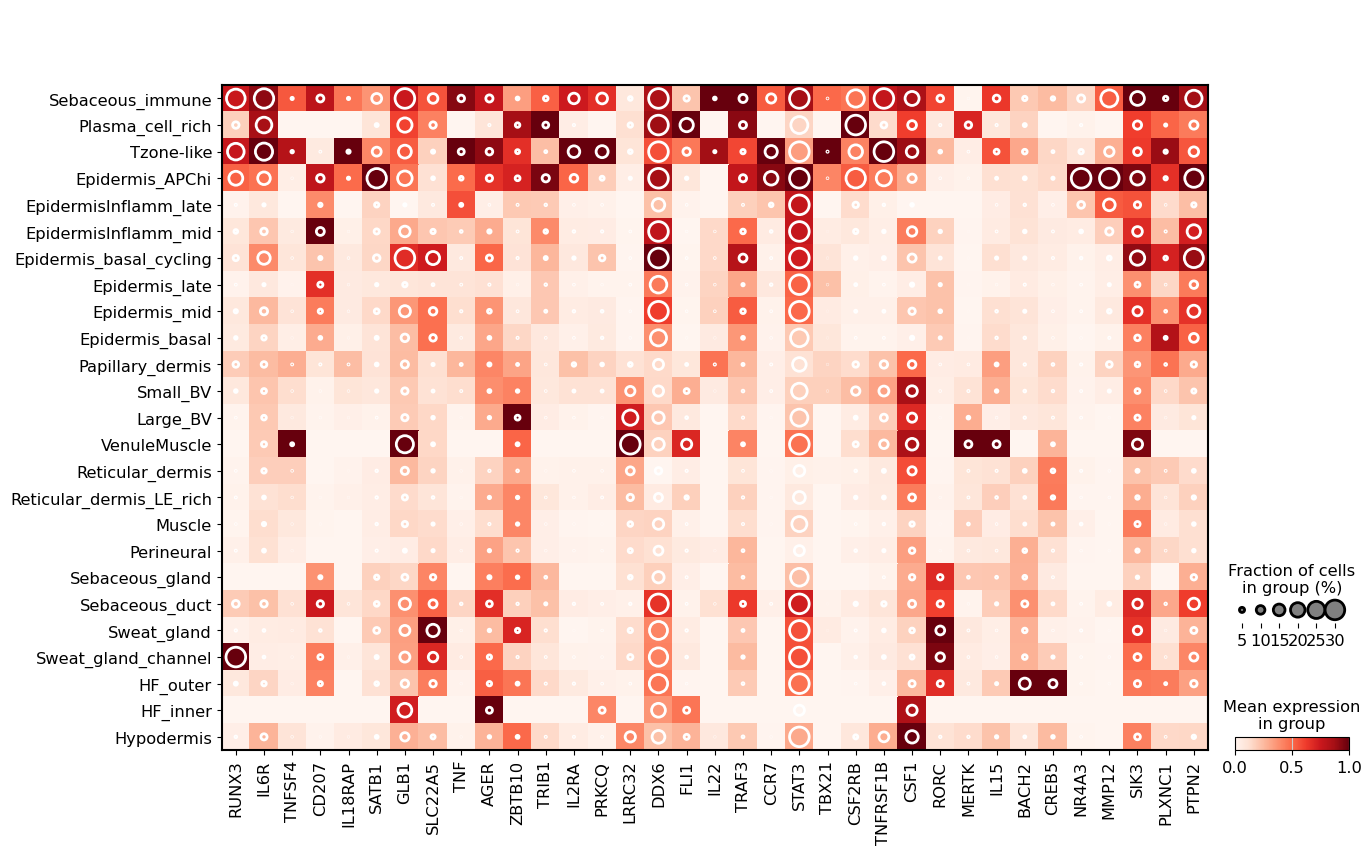

In [16]:
dp = sc.pl.DotPlot(
            adata_5k_ii, #[adata_5k_i.obs["Site_status_binary"]=="Lesional"],
            remove_markers(AD_GENES_OT),#[:40],
            #swap_axes=True,
            groupby="niche19",
           vmax=1,
            #    colorbar_title='Mean expression\n(variance scaled)', 
         standard_scale="var",
           # save="5g_AD.pdf",
        ) 
dp = dp.style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=2, grid=False, #vmax=.8
                       dot_max=.3

                  )
#dp.show()     
dp.savefig("supp_celltypesHEATMAP_gwas_ad.pdf", dpi=300)       
    

In [17]:
CONTROL_SIZE = 1000 #
N_BINS=25  
adata_5k_i = sc.tl.score_genes(adata_5k_i, remove_markers(AD_GENES_OT), ctrl_size=CONTROL_SIZE, n_bins=N_BINS, copy=True, score_name="ad_gwas")



In [18]:
import pickle

# Path to your pickle file
path = "/nfs/team298/ls34/niche_colors.pkl"

# Load the dictionary
with open(path, "rb") as f:
    colors_new2 = pickle.load(f)

In [19]:
# Count cells per niche
counts = adata_5k_i.obs["niche19"].value_counts()

# Keep only niches with >=10 cells
valid_niches = counts[counts >= 10].index

# Subset AnnData
adata_5k_i = adata_5k_i[adata_5k_i.obs["niche19"].isin(valid_niches)].copy()

# Clean up unused categories
adata_5k_i.obs["niche19"] = adata_5k_i.obs["niche19"].cat.remove_unused_categories()



/tmp/ipykernel_1289556/2320386308.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("niche19")["ad_gwas"]
/tmp/ipykernel_1289556/2320386308.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1289556/2320386308.py:14: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


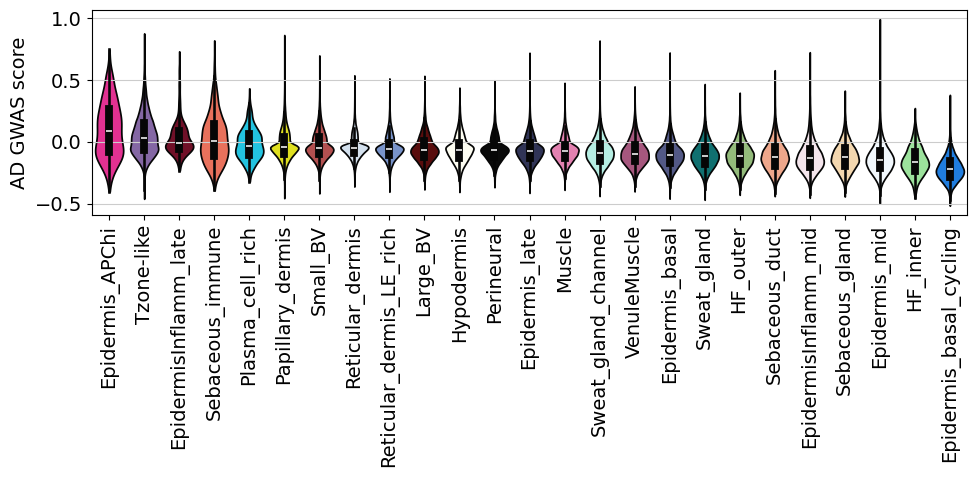

In [20]:

# Extract the obs as DataFrame
df = adata_5k_i.obs[["niche19", "ad_gwas"]].copy()

# Compute mean per niche and sort descending
order = (
    df.groupby("niche19")["ad_gwas"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# Make violin plot
plt.figure(figsize=(10, 5))
sns.violinplot(
    data=df,
    x="niche19",
    y="ad_gwas",
    order=order,
    inner="box",   # optional: show a mini boxplot inside
    cut=0,         # don’t extend violins beyond observed data
    scale="width" , # makes widths comparable
    palette=colors_new2  
)

plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("AD GWAS score")
plt.title("")
plt.tight_layout()
plt.savefig("9b_ad_violin_GWAS.pdf", dpi=300, bbox_inches="tight")

plt.show()



In [21]:
COLOR_PICKLE_PATH= '/nfs/team298/ls34/color_for_adult_skin2.pkl'
# # Load colors
with open(COLOR_PICKLE_PATH, 'rb') as f:
    colors = pickle.load(f)

/tmp/ipykernel_1289556/760190528.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("lvl5_annotation")["ad_gwas"]
/tmp/ipykernel_1289556/760190528.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1289556/760190528.py:14: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


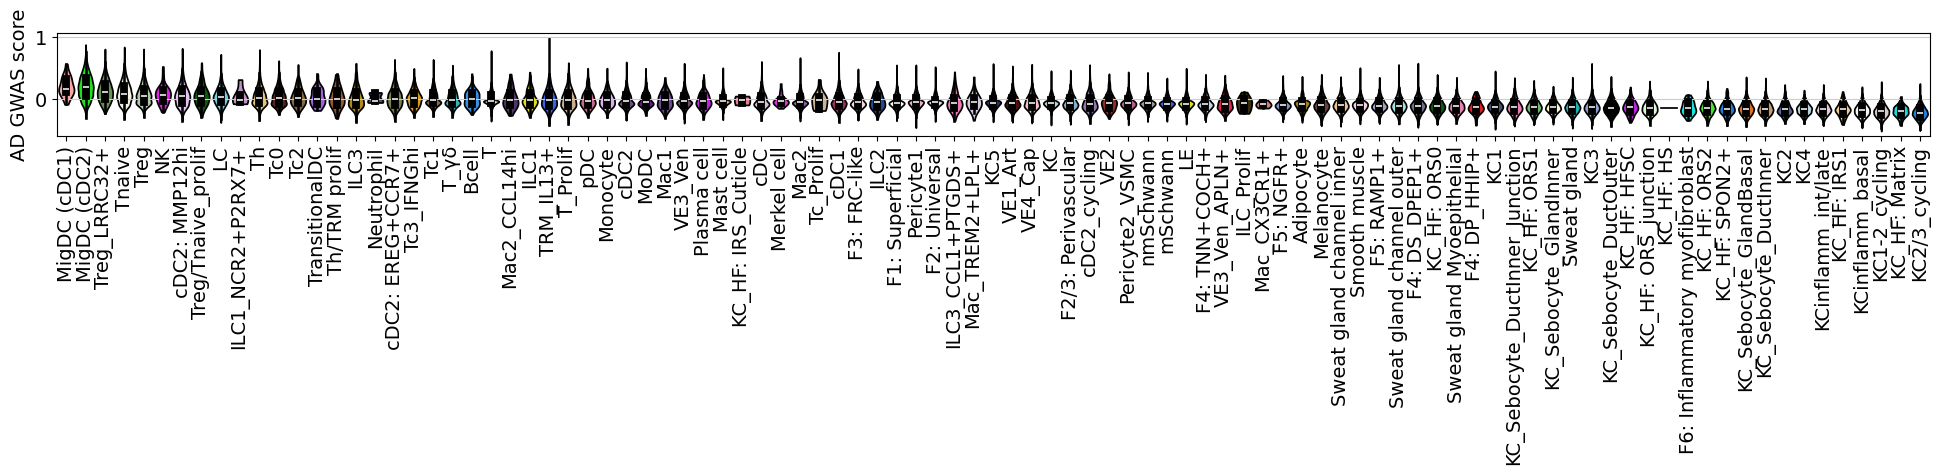

In [22]:

# Extract the obs as DataFrame
df = adata_5k_i.obs[["lvl5_annotation", "ad_gwas"]].copy()

# Compute mean per niche and sort descending
order = (
    df.groupby("lvl5_annotation")["ad_gwas"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# Make violin plot
plt.figure(figsize=(20, 5))
sns.violinplot(
    data=df,
    x="lvl5_annotation",
    y="ad_gwas",
    order=order,
    inner="box",   # optional: show a mini boxplot inside
    cut=0,         # don’t extend violins beyond observed data
    scale="width" , # makes widths comparable
        palette=colors 

)

plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("AD GWAS score")
plt.title(" ", )
plt.tight_layout()
plt.savefig("supp9b_ad_violin_celltype.pdf", dpi=300, bbox_inches="tight")

plt.show()

# psoriasis GWAS

In [23]:
psoriasis_genes = [
    
    "IL23R",
    "FSD1",
    "FUT2",
    "STAP2",
    "CPVL",
    "POU2F3",
    "TRAF3IP2",
    "TYK2",
     "SH2B3",
    "ERAP1",
    "CARD14",
    
    
    "PARK7", "ERRFI1", "PLOD1", "RUNX3", "IL12RB2", "LCE3C", "KPRP", "CRB1",
    "PTPRC", "KDM5B", "CYB5R1", "POMC", "NRBP1", "PUS10", "C2ORF74", "AHSA2",
    "B3GNT2", "ACOXL", "KCNH7", "PLCL2", "CEP97", "ZPLD1", "LEKR1", "TP63",
    "CCNA2", "IL7R", "CAST", "HINT1", "SLC22A4", "CSF1R", "FGFR4", "IRF4",
    "CDKAL1", "SLC17A3", "SLC17A2", "PSMB9", "ITPR3", "GRM4", "BEND3", "FYN",
    "IFNGR1", "TAGAP", "ELMO1", "MYC", "ACO1", "DDX58", "NDUFB6", "FAM206A",
    "IL2RA", "PLAU", "ADK", "ZMIZ1", "PPIF", "PRR5L", "RPS6KA4", "ESRRA",
    "MAP3K11", "ZC3H12C", "GRIK4", "ETS1", "KCNJ1", "ERBB3", "COG6", "FOXO1",
    "PSMA6", "ATP10A", "KLF13", "CLEC16A", "RMI2", "CTD-3088G3.8", "ITGAX",
    "LGALS9", "KCNH4", "HSD17B1", "PHOSPHO1", "GALK1", "CARD14", "SGSH",
    "TUBB6", "PTPN2", "POLI", "STARD6", "TYK2", "S1PR5", "DNMT3B", "PTPN1",
    "IFNAR1", "RUNX1", "PPIL2"
]
seen=[]
newli=[]
for x in psoriasis_genes:
    if x not in seen:
        newli.append(x)
        seen.append(x)
    else:
        continue
psoriasis_genes=remove_markers(newli)



In [24]:
adata_5k_i=adata_5k[adata_5k.obs["disease_overall"]=="Psoriasis"]
adata_5k_i.shape

(398025, 4993)

In [25]:
adata_5k_i=adata_5k_i[adata_5k_i.obs["niche19"]!="Nonspecific/folded"]
adata_5k_i=adata_5k_i[~adata_5k_i.obs["niche19"].isna()]
adata_5k_ii=adata_5k_i[adata_5k_i.obs["Site_status"]=="Lesional"]



In [26]:
count=0
for x in adata_5k_i.obs["niche19"].unique():
    if x not in desired_order:
        print(x)
        count = count+1
if count != 0: 
    stop


In [27]:
adata_5k_ii.obs["niche19"] = pd.Categorical(
    adata_5k_ii.obs["niche19"],
    categories=desired_order,
    ordered=True
)



/tmp/ipykernel_1289556/2271436822.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_5k_ii.obs["niche19"] = pd.Categorical(


In [28]:
counts = adata_5k_ii.obs["niche19"].value_counts()
valid_niches = counts[counts > 10].index
adata_5k_ii = adata_5k_ii[adata_5k_ii.obs["niche19"].isin(valid_niches)].copy()


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:731: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  

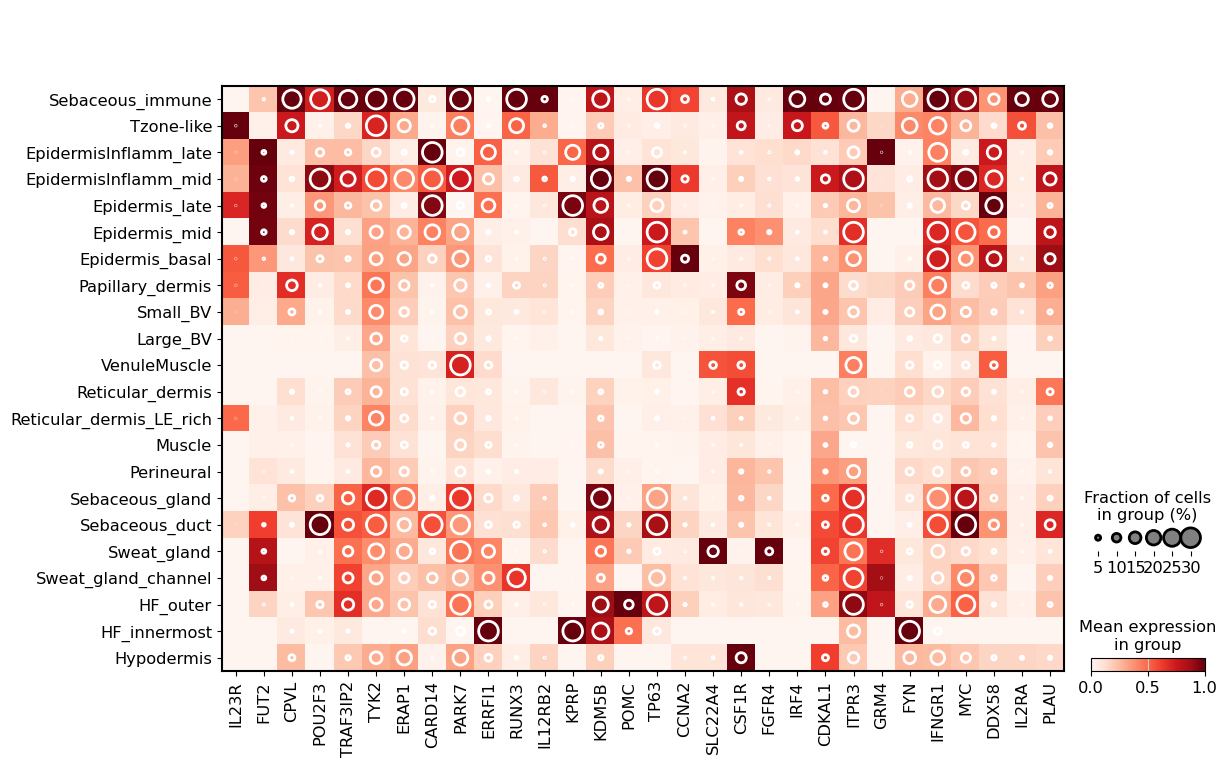

In [29]:
dp = sc.pl.DotPlot(
        adata_5k_ii,
        remove_markers(psoriasis_genes)[:30],
        #swap_axes=True,
        groupby="niche19",
       vmax=1,
        #    colorbar_title='Mean expression\n(variance scaled)', 
     standard_scale="var",

    ) 
dp = dp.style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=2, grid=False, #vmax=.8
                   dot_max=.3

              )

dp.savefig("supp_celltypesHEATMAP_gwas_pso.pdf", dpi=300)       


In [30]:
CONTROL_SIZE = 1000 #
N_BINS=25  
adata_5k_ii = sc.tl.score_genes(adata_5k_ii, remove_markers(psoriasis_genes), ctrl_size=CONTROL_SIZE, n_bins=N_BINS, copy=True, score_name="pso_gwas")



/tmp/ipykernel_1289556/1390896741.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("niche19")["pso_gwas"]
/tmp/ipykernel_1289556/1390896741.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1289556/1390896741.py:11: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


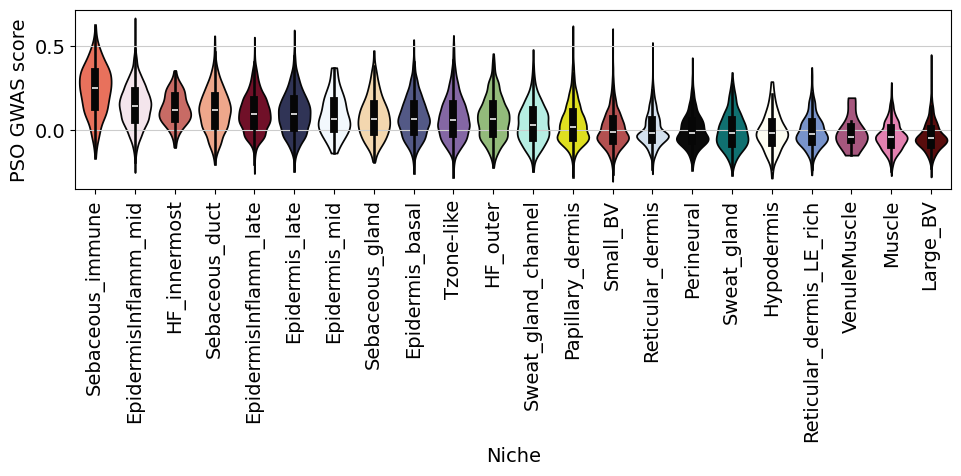

In [31]:
df = adata_5k_ii.obs[["niche19", "pso_gwas"]].copy()

order = (
    df.groupby("niche19")["pso_gwas"]
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10, 5))
sns.violinplot(
    data=df,
    x="niche19",
    y="pso_gwas",
    order=order,
    inner="box",    
    cut=0,       
    scale="width" ,  
    palette=colors_new2  ,

)

plt.xticks(rotation=90)
plt.xlabel("Niche")
plt.ylabel("PSO GWAS score")
plt.title("")
plt.tight_layout()
plt.savefig("supp9b_pso_violin_GWAS.pdf", dpi=300, bbox_inches="tight")
plt.show()



/tmp/ipykernel_1289556/1834851090.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("lvl5_annotation")["pso_gwas"]
/tmp/ipykernel_1289556/1834851090.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1289556/1834851090.py:11: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


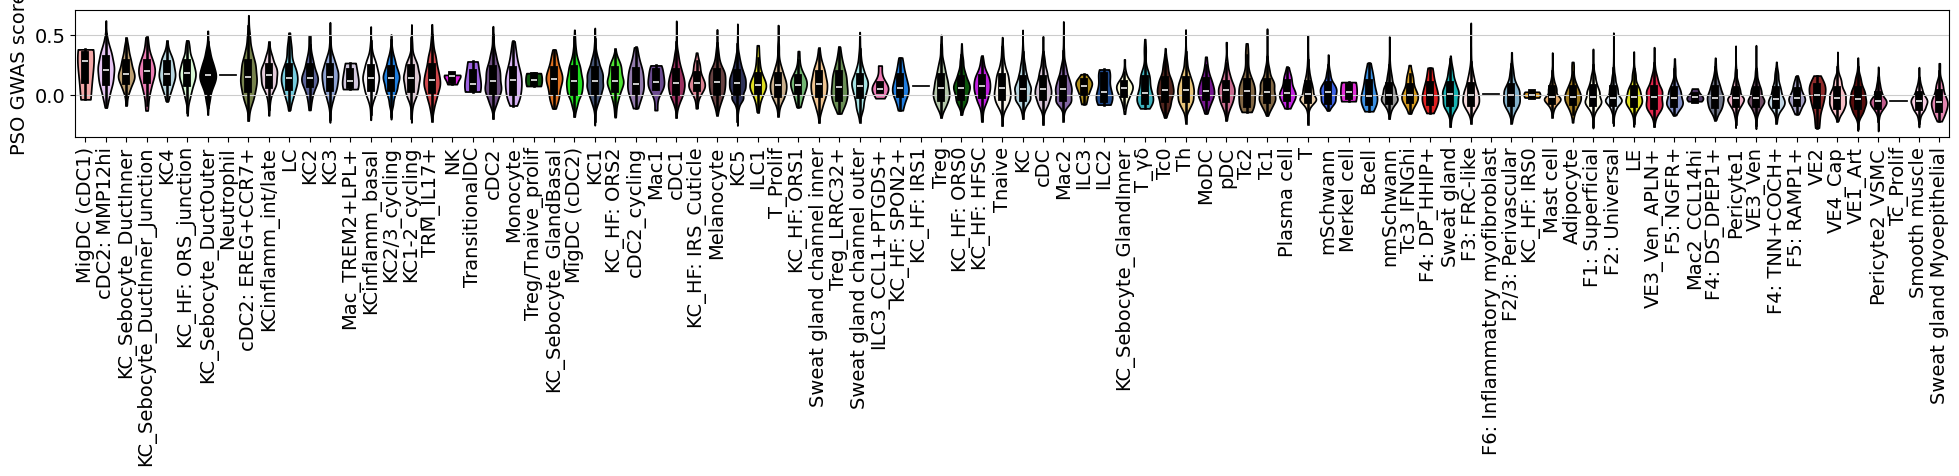

In [32]:
df = adata_5k_ii.obs[["lvl5_annotation", "pso_gwas"]].copy()

order = (
    df.groupby("lvl5_annotation")["pso_gwas"]
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(20, 5))
sns.violinplot(
    data=df,
    x="lvl5_annotation",
    y="pso_gwas",
    order=order,
    inner="box",   
    cut=0,        
    scale="width",  
                palette=colors 

)

plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("PSO GWAS score")
plt.title("")
plt.tight_layout()

plt.savefig("supp9b_PSO_violin_celltype.pdf", dpi=300, bbox_inches="tight")
plt.show()